In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    precision_score, recall_score, f1_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

In [45]:
df_raw = pd.read_csv('credit_risk_dataset.csv')
print(f"Raw Data Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head()

Raw Data Loaded: 1000 rows, 8 columns.


,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


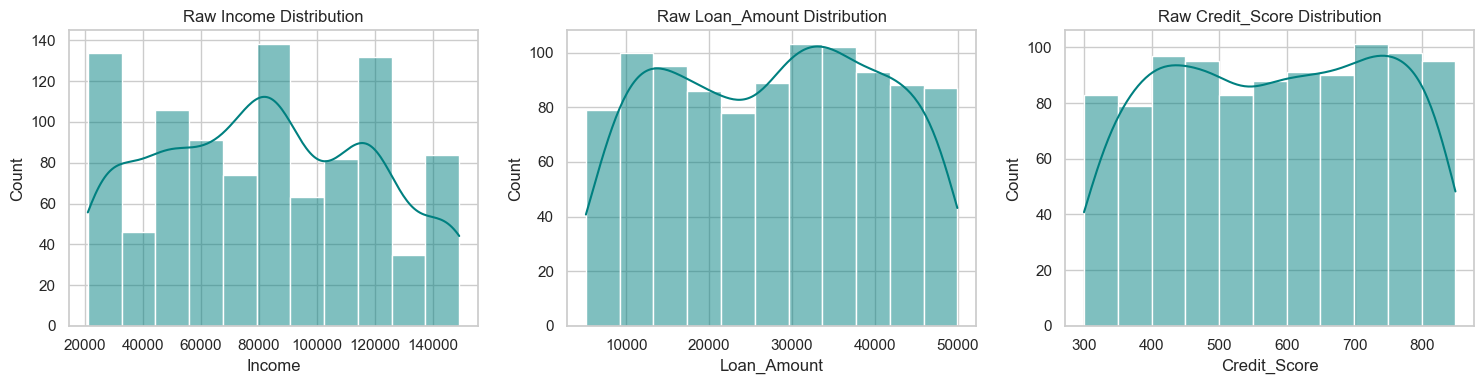

In [46]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(['Income', 'Loan_Amount', 'Credit_Score']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_raw[col], kde=True, color='teal')
    plt.title(f'Raw {col} Distribution')
plt.tight_layout()
plt.show()

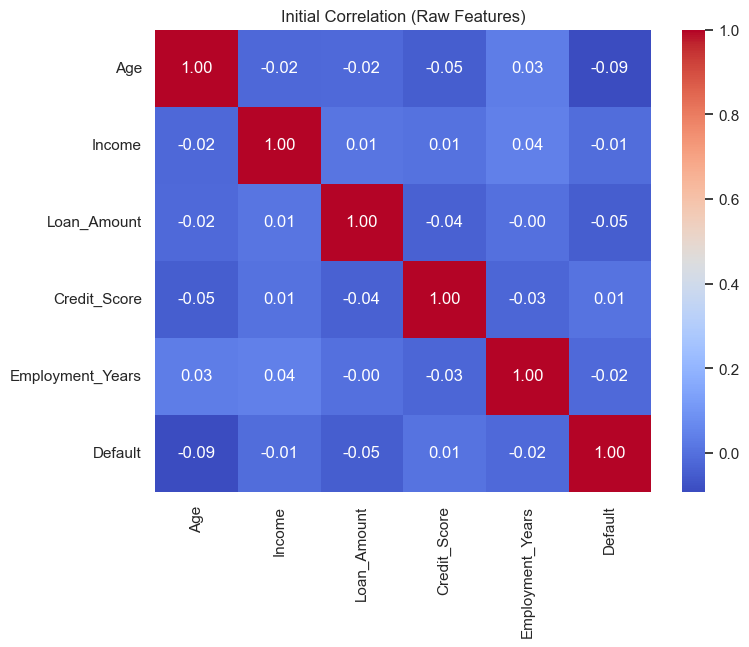

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Initial Correlation (Raw Features)")
plt.show()

###  Feature Engineering Logic

**What**: Deriving 3 new interaction features.

**How**: Creating ratios and combined indices:
- **Loan-to-Income**: Relative burden.
- **Stability Index**: Longevity vs Credibility.
- **Risk Index**: Debt density vs Repayment potential.

**Why**: In lending, a "$50k loan is risky for someone earning $30k", but safe for someone earning $300k. The ratio is the true signal.

In [49]:
df = df_raw.copy()
df['Loan_to_Income_Ratio'] = df['Loan_Amount'] / (df['Income'] + 1)
df['Stability_Index'] = df['Credit_Score'] * df['Employment_Years']
df['Risk_Index'] = (df['Loan_Amount'] / (df['Income'] + 1)) / (df['Credit_Score'] + 1)

###  Comparative Signal (New Feature Impact)

**What**: Visualizing how the new features separate the classes.

**How**: Boxplotting the engineered `Risk_Index` against the target `Default`.

**Why**: To visually confirm that our engineered features have a clear difference in median values for 'Safe' (0) vs 'Default' (1) borrowers.

C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_19660\2660370137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default', y='Risk_Index', data=df, palette="Set2")


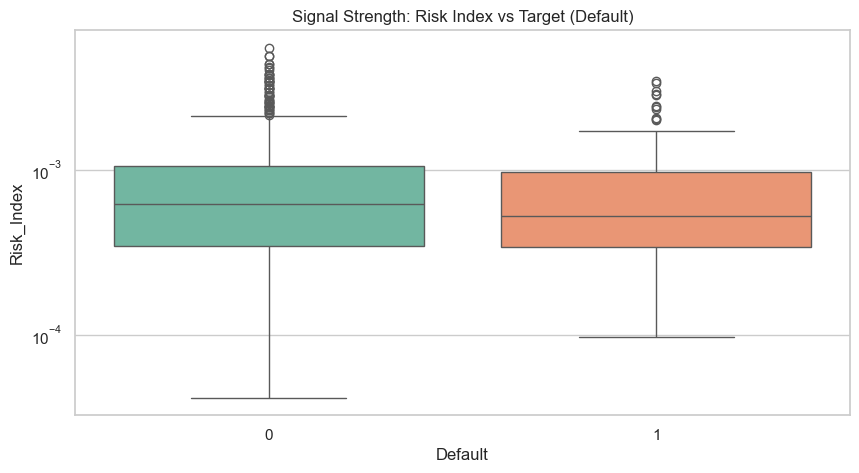

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Default', y='Risk_Index', data=df, palette="Set2")
plt.title("Signal Strength: Risk Index vs Target (Default)")
plt.yscale('log') # Log scale helps see the separation clearly
plt.show()

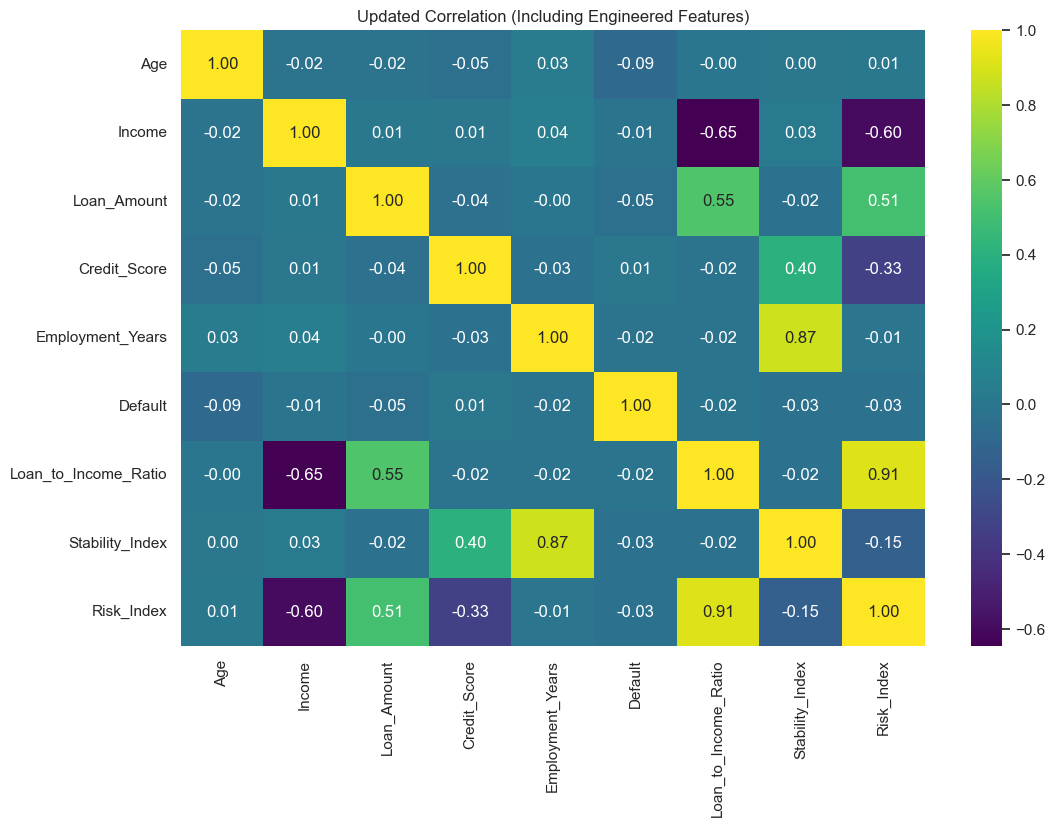

In [52]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title("Updated Correlation (Including Engineered Features)")
plt.show()

In [53]:
X = df.drop(columns=['Default'])
y = df['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")

Training set: 800 rows | Test set: 200 rows


###  Encoding (ColumnTransformer)

**What**: Defining the multi-path preprocessing logic.

**How**: Creating 3 distinct pipelines:
- **Numeric**: `Imputer` -> `Scaler`
- **Ordinal**: Fixed mapping for education levels.
- **Nominal**: `OneHotEncoder` for housing categories.

**Why**: Using pipelines prevents leakage by ensuring every transformation step is consistently applied during both training and production inference.

In [55]:
num_cols = ['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Loan_to_Income_Ratio', 'Stability_Index', 'Risk_Index']
ord_cols = ['Education_Level']
nom_cols = ['Housing_Status']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), num_cols),
    ('ord', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]), ord_cols),
    ('nom', OneHotEncoder(drop='first', sparse_output=False), nom_cols)
])

print("Transformation Engine configured.")

Transformation Engine configured.


In [56]:
X_train_final = pd.DataFrame(preprocessor.fit_transform(X_train), columns=[n.split('__')[-1] for n in preprocessor.get_feature_names_out()])
X_test_final = pd.DataFrame(preprocessor.transform(X_test), columns=[n.split('__')[-1] for n in preprocessor.get_feature_names_out()])
print("Transformation complete.")

Transformation complete.


###  SMOTE Balancing

**What**: Applying Synthetic Minority Over-sampling.

**How**: Upsampling the 'Default' class in the training set to reach 50/50 balance.

**Why**: Models naturally follow the majority (0). SMOTE creates new 'synthetic' defaults based on k-nearest neighbors to force the model to learn the risk signal.

In [58]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_final, y_train)
print(f"New Balanced State: {y_res.value_counts().to_dict()}")

New Balanced State: {0: 690, 1: 690}


C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_19660\2913352144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.subplot(1, 2, 1); sns.countplot(x=y_train, palette="Set2").set_title("Original (Imbalanced)")
C:\Users\DHANANJAY\AppData\Local\Temp\ipykernel_19660\2913352144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt.subplot(1, 2, 2); sns.countplot(x=y_res, palette="Set1").set_title("Balanced (SMOTE)")


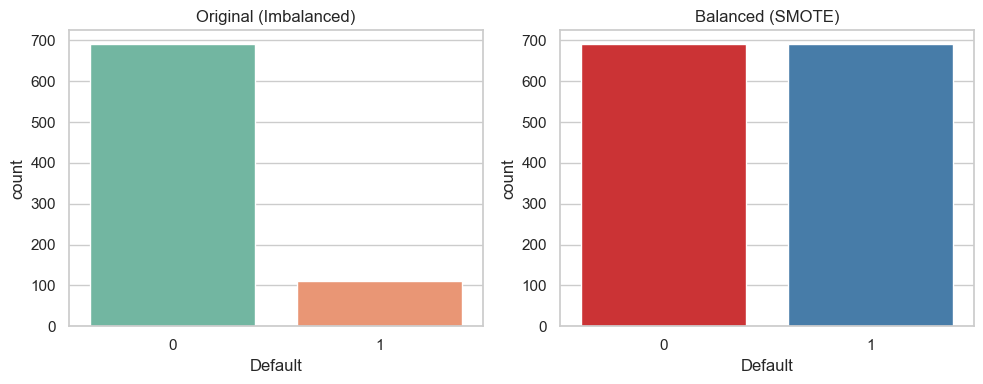

In [59]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); sns.countplot(x=y_train, palette="Set2").set_title("Original (Imbalanced)")
plt.subplot(1, 2, 2); sns.countplot(x=y_res, palette="Set1").set_title("Balanced (SMOTE)")
plt.tight_layout(); plt.show()

In [60]:
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_res, y_res)

LogisticRegression(max_iter=2000, random_state=42)

###  Precision-Recall Optimization Curve

**What**: Visualizing the trade-off between false positives and false negatives.

**How**: Plotting Precision vs Recall across all possible probability thresholds.

**Why**: This chart reveals why we selected the **0.40 threshold**. In banking, missing a default is a catastrophic loss, making a lower threshold (more sensitive) the optimal business decision.

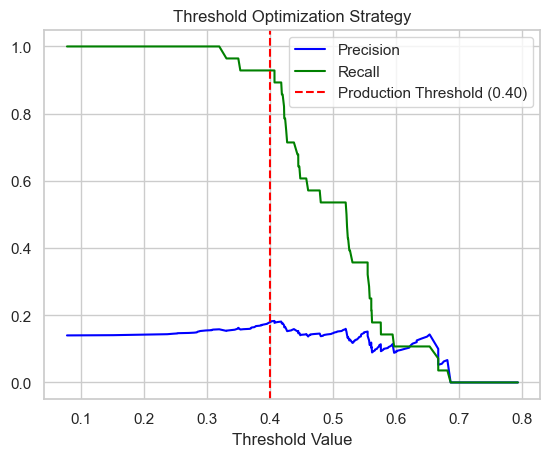

In [62]:
probs = model.predict_proba(X_test_final)[:, 1]
precs, recs, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precs[:-1], label='Precision', color='blue')
plt.plot(thresholds, recs[:-1], label='Recall', color='green')
plt.axvline(x=0.40, color='red', linestyle='--', label='Production Threshold (0.40)')
plt.xlabel('Threshold Value')
plt.title('Threshold Optimization Strategy')
plt.legend() 
plt.show()

In [63]:
final_preds = (probs >= 0.40).astype(int)
print(f"Final Recall for T=0.40: {recall_score(y_test, final_preds):.2%}")
print(f"Final Precision for T=0.40: {precision_score(y_test, final_preds):.2%}")
print(f"Final F1 Score: {f1_score(y_test, final_preds):.2f}")

Final Recall for T=0.40: 92.86%
Final Precision for T=0.40: 18.06%
Final F1 Score: 0.30


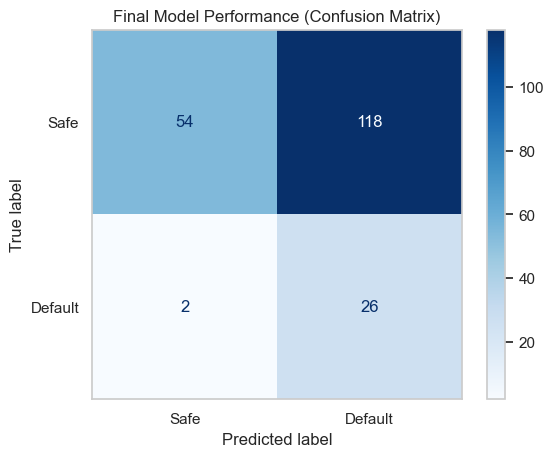

In [64]:
cm = confusion_matrix(y_test, final_preds)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Default'])
cmd.plot(cmap='Blues')
plt.grid(False)
plt.title('Final Model Performance (Confusion Matrix)')
plt.show()